In [ ]:
!pip install -q hmmlearn

import pandas as pd
import numpy as np
import re
import os
import pickle
import nltk
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc,
                             classification_report)
from hmmlearn.hmm import CategoricalHMM
from nltk.tokenize import word_tokenize

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('averaged_perceptron_tagger')
nltk.download('averaged_perceptron_tagger_eng')

print("All imports ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 166.0/166.0 kB 5.4 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package averaged_perceptron_tagger to
[nltk_data]     /root/nltk_data...


All imports ready.


[nltk_data]   Unzipping taggers/averaged_perceptron_tagger.zip.
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DRIVE = '/content/drive/My Drive/SarcasmProject'
df = pd.read_csv(f'{DRIVE}/data/processed_data.csv')
print(f"Full dataset: {len(df):,} rows")

# Subset for HMM (POS tagging is slow on full data)
SUBSET = 50000
df_sub = df.sample(n=SUBSET, random_state=42).reset_index(drop=True)

# 80/20 split — same seed for ALL models
train_df, test_df = train_test_split(
    df_sub, test_size=0.2, random_state=42, stratify=df_sub['label']
)
train_df = train_df.reset_index(drop=True)
test_df = test_df.reset_index(drop=True)

print(f"Train: {len(train_df)}, Test: {len(test_df)}")

Mounted at /content/drive
Full dataset: 1,010,771 rows
Train: 40000, Test: 10000


In [ ]:
def get_pos_tags(text):
    text = str(text).lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)
    text = re.sub(r'[^a-z\s]', '', text)
    tokens = word_tokenize(text)
    if len(tokens) < 3:
        return None
    return [tag for _, tag in nltk.pos_tag(tokens)]

tqdm.pandas()

print("POS tagging train set... (takes ~2 min)")
train_df['pos'] = train_df['comment'].progress_apply(get_pos_tags)
train_df = train_df.dropna(subset=['pos']).reset_index(drop=True)

print("POS tagging test set...")
test_df['pos'] = test_df['comment'].progress_apply(get_pos_tags)
test_df = test_df.dropna(subset=['pos']).reset_index(drop=True)

print(f"Train: {len(train_df)}, Test: {len(test_df)} (after filtering short comments)")

# Show examples
print("\n=== POS Tag Examples ===")
for i in range(3):
    print(f"Text: {train_df['comment'].iloc[i][:60]}...")
    print(f"Tags: {train_df['pos'].iloc[i][:10]}")
    print(f"Label: {'Sarcastic' if train_df['label'].iloc[i] == 1 else 'Genuine'}\n")


POS tagging train set... (takes ~2 min)


100%|██████████| 40000/40000 [00:26<00:00, 1502.81it/s]


POS tagging test set...


100%|██████████| 10000/10000 [00:05<00:00, 1935.41it/s]

Train: 36130, Test: 8992 (after filtering short comments)

=== POS Tag Examples ===
Text: when I go i'm taking you all with me...
Tags: ['WRB', 'NN', 'VBP', 'RB', 'VBG', 'PRP', 'DT', 'IN', 'PRP']
Label: Sarcastic

Text: cool story bro...
Tags: ['JJ', 'NN', 'NN']
Label: Genuine

Text: I'm not saying I don't like Thugger, and also, have you seen...
Tags: ['NN', 'RB', 'VBG', 'JJ', 'VBP', 'IN', 'NN', 'CC', 'RB', 'VBP']
Label: Genuine



In [ ]:
# Build tag vocabulary
all_tags = set()
for seq in list(train_df['pos']) + list(test_df['pos']):
    all_tags.update(seq)
tag_to_int = {tag: i for i, tag in enumerate(sorted(all_tags))}
n_tags = len(tag_to_int)
print(f"Unique POS tags: {n_tags}")

def encode(pos_seq):

    return np.array([[tag_to_int[t]] for t in pos_seq if t in tag_to_int])

def prepare_class_data(dataframe, label):
    #Concatenate all sequences of one class for HMM training.
    seqs, lens = [], []
    for _, row in dataframe[dataframe['label'] == label].iterrows():
        enc = encode(row['pos'])
        if len(enc) >= 3:
            seqs.append(enc)
            lens.append(len(enc))
    return np.concatenate(seqs), lens

# Prepare data
X_genuine, len_genuine = prepare_class_data(train_df, 0)
X_sarcastic, len_sarcastic = prepare_class_data(train_df, 1)
print(f"Genuine sequences: {len(len_genuine)}, tokens: {len(X_genuine)}")
print(f"Sarcastic sequences: {len(len_sarcastic)}, tokens: {len(X_sarcastic)}")

N_HIDDEN = 4

# Uniform initialization = Laplace-like prior
init_transmat = np.full((N_HIDDEN, N_HIDDEN), 1.0 / N_HIDDEN)
init_emissionprob = np.full((N_HIDDEN, n_tags), 1.0 / n_tags)
init_startprob = np.full(N_HIDDEN, 1.0 / N_HIDDEN)

print("\nTraining HMM for genuine comments...")
hmm_genuine = CategoricalHMM(n_components=N_HIDDEN, n_iter=30,
                              random_state=42, n_features=n_tags,
                              init_params='')  # we set params manually
hmm_genuine.startprob_ = init_startprob.copy()
hmm_genuine.transmat_ = init_transmat.copy()
hmm_genuine.emissionprob_ = init_emissionprob.copy()
hmm_genuine.fit(X_genuine, len_genuine)
# Laplace floor — prevent any post-training zeros
hmm_genuine.transmat_ = np.maximum(hmm_genuine.transmat_, 1e-6)
hmm_genuine.emissionprob_ = np.maximum(hmm_genuine.emissionprob_, 1e-6)
print("✓ Done (with Laplace smoothing)")

print("Training HMM for sarcastic comments...")
hmm_sarcastic = CategoricalHMM(n_components=N_HIDDEN, n_iter=30,
                                random_state=42, n_features=n_tags,
                                init_params='')
hmm_sarcastic.startprob_ = init_startprob.copy()
hmm_sarcastic.transmat_ = init_transmat.copy()
hmm_sarcastic.emissionprob_ = init_emissionprob.copy()
hmm_sarcastic.fit(X_sarcastic, len_sarcastic)
hmm_sarcastic.transmat_ = np.maximum(hmm_sarcastic.transmat_, 1e-6)
hmm_sarcastic.emissionprob_ = np.maximum(hmm_sarcastic.emissionprob_, 1e-6)
print("✓ Done")

# Show transition matrices (the learned grammar patterns)
print("\n=== Transition Matrix — Genuine ===")
print("(Each row shows P(next_state | current_state))")
print(np.round(hmm_genuine.transmat_, 3))

print("\n=== Transition Matrix — Sarcastic ===")
print(np.round(hmm_sarcastic.transmat_, 3))

Unique POS tags: 37
Genuine sequences: 17420, tokens: 202862
Sarcastic sequences: 18710, tokens: 204065

Training HMM for genuine comments...
✓ Done (with Laplace smoothing)
Training HMM for sarcastic comments...
✓ Done

=== Transition Matrix — Genuine ===
(Each row shows P(next_state | current_state))
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]

=== Transition Matrix — Sarcastic ===
[[0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]
 [0.25 0.25 0.25 0.25]]


=== Viterbi Decoding — Example Sentences ===

Text: I can vouch for the quality of this slip - over 3 years of use and it'...
True label: GENUINE
POS tags:        ['NN', 'MD', 'VB', 'IN', 'DT', 'NN', 'IN', 'DT']...
Hidden (genuine):  [np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3)]...
Hidden (sarcasm):  [np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3)]...

Text: 70 damage is too low for a lategame gods early clear, after all, no re...
True label: GENUINE
POS tags:        ['NN', 'VBZ', 'RB', 'JJ', 'IN', 'DT', 'JJ', 'NNS']...
Hidden (genuine):  [np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3)]...
Hidden (sarcasm):  [np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3), np.int64(3)]...

Text: Eh British people are weird about showing affection...
True label: SARCASTIC
POS tags:        ['JJ

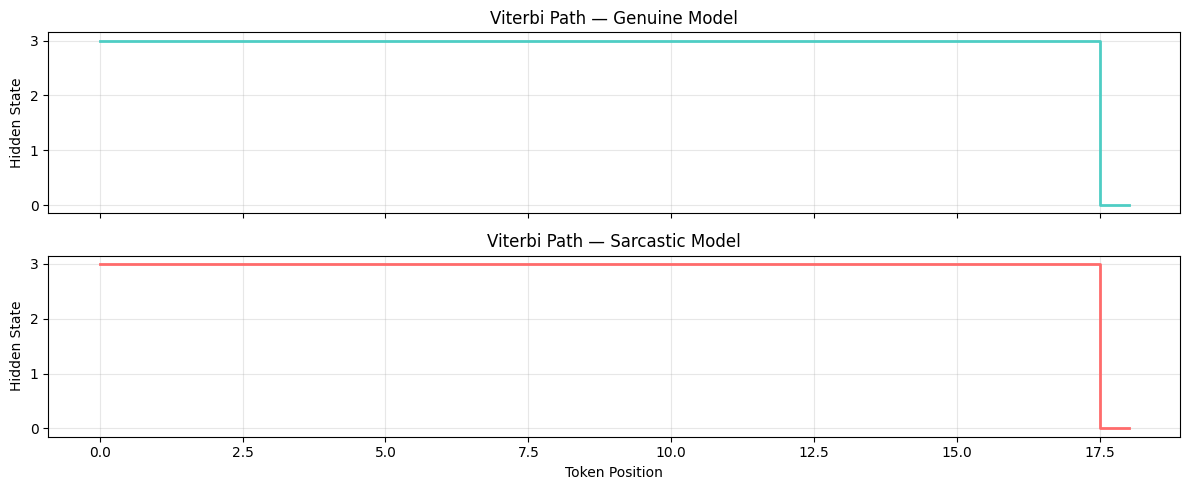

✓ Saved: hmm_viterbi.png
Notice: the two models assign DIFFERENT hidden state paths
to the same sentence — that's how classification works.



In [ ]:
int_to_tag = {v: k for k, v in tag_to_int.items()}

print("=== Viterbi Decoding — Example Sentences ===\n")

# Pick a few test examples (both sarcastic and genuine)
examples = test_df.head(6)

for _, row in examples.iterrows():
    enc = encode(row['pos'])
    if len(enc) < 3:
        continue

    # Viterbi: find most likely hidden state sequence
    hidden_genuine = hmm_genuine.predict(enc)
    hidden_sarcastic = hmm_sarcastic.predict(enc)

    label = "SARCASTIC" if row['label'] == 1 else "GENUINE"
    tags = [int_to_tag.get(e[0], '?') for e in enc]

    print(f"Text: {str(row['comment'])[:70]}...")
    print(f"True label: {label}")
    print(f"POS tags:        {tags[:8]}{'...' if len(tags) > 8 else ''}")
    print(f"Hidden (genuine):  {list(hidden_genuine[:8])}{'...' if len(hidden_genuine) > 8 else ''}")
    print(f"Hidden (sarcasm):  {list(hidden_sarcastic[:8])}{'...' if len(hidden_sarcastic) > 8 else ''}")
    print()

# Visualize Viterbi path for one sentence
sample = test_df.iloc[0]
enc = encode(sample['pos'])
path_g = hmm_genuine.predict(enc)
path_s = hmm_sarcastic.predict(enc)
tags = [int_to_tag.get(e[0], '?') for e in enc]

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)

axes[0].step(range(len(path_g)), path_g, where='mid', color='#4ECDC4', linewidth=2)
axes[0].set_ylabel('Hidden State')
axes[0].set_title('Viterbi Path — Genuine Model', fontsize=12)
axes[0].set_yticks(range(N_HIDDEN))
axes[0].grid(alpha=0.3)

axes[1].step(range(len(path_s)), path_s, where='mid', color='#FF6B6B', linewidth=2)
axes[1].set_ylabel('Hidden State')
axes[1].set_title('Viterbi Path — Sarcastic Model', fontsize=12)
axes[1].set_yticks(range(N_HIDDEN))
axes[1].set_xlabel('Token Position')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{DRIVE}/outputs/hmm_viterbi.png', dpi=150)
plt.show()
print("✓ Saved: hmm_viterbi.png")
print("Notice: the two models assign DIFFERENT hidden state paths")
print("to the same sentence — that's how classification works.\n")


In [ ]:
y_true, y_pred, y_prob = [], [], []

for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Classifying"):
    enc = encode(row['pos'])
    if len(enc) < 3:
        continue
    try:
        s0 = hmm_genuine.score(enc)
        s1 = hmm_sarcastic.score(enc)
        pred = 1 if s1 > s0 else 0
        diff = np.clip(s1 - s0, -500, 500)
        prob = 1.0 / (1.0 + np.exp(-diff))  # sigmoid
        y_true.append(row['label'])
        y_pred.append(pred)
        y_prob.append(prob)
    except:
        continue

y_true = np.array(y_true)
y_pred = np.array(y_pred)
y_prob = np.array(y_prob)

# Metrics
acc = accuracy_score(y_true, y_pred)
prec = precision_score(y_true, y_pred)
rec = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

print("\n" + "=" * 40)
print("     HMM BASELINE — RESULTS")
print("=" * 40)
print(f"  Accuracy:  {acc:.4f} ({acc*100:.1f}%)")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1 Score:  {f1:.4f}")
print("=" * 40)
print(classification_report(y_true, y_pred, target_names=['Genuine', 'Sarcastic']))


Classifying: 100%|██████████| 8992/8992 [00:11<00:00, 815.32it/s] 



     HMM BASELINE — RESULTS
  Accuracy:  0.5380 (53.8%)
  Precision: 0.5598
  Recall:    0.5142
  F1 Score:  0.5361
              precision    recall  f1-score   support

     Genuine       0.52      0.56      0.54      4325
   Sarcastic       0.56      0.51      0.54      4667

    accuracy                           0.54      8992
   macro avg       0.54      0.54      0.54      8992
weighted avg       0.54      0.54      0.54      8992



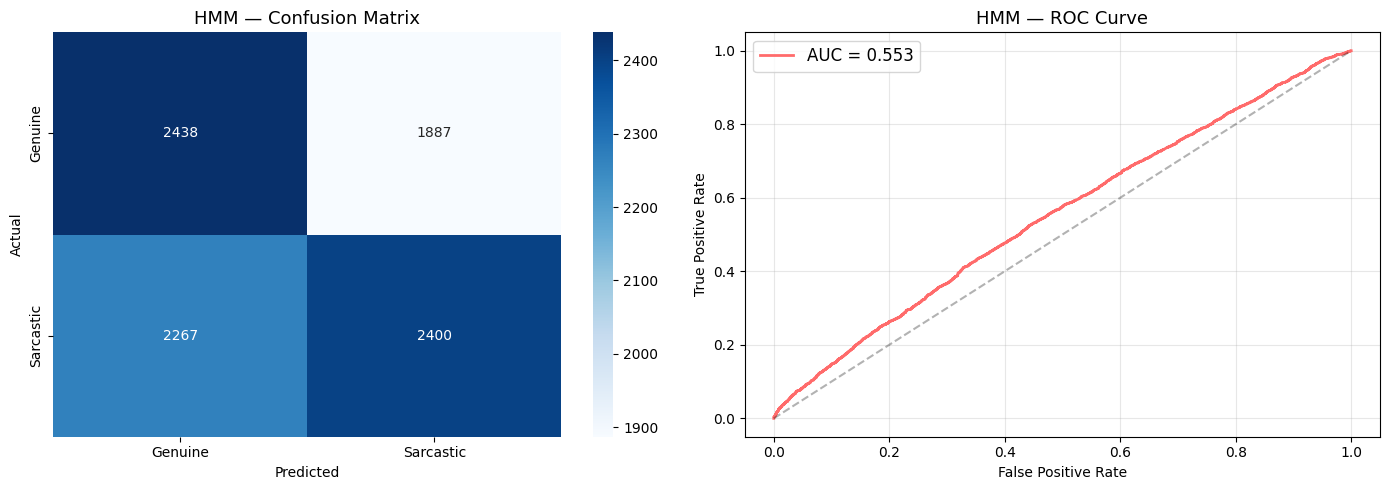

✓ Saved: hmm_results.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['Genuine', 'Sarcastic'],
            yticklabels=['Genuine', 'Sarcastic'])
axes[0].set_title('HMM — Confusion Matrix', fontsize=13)
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# ROC Curve
fpr, tpr, _ = roc_curve(y_true, y_prob)
roc_auc = auc(fpr, tpr)
axes[1].plot(fpr, tpr, color='#FF6B6B', linewidth=2, label=f'AUC = {roc_auc:.3f}')
axes[1].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title('HMM — ROC Curve', fontsize=13)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend(fontsize=12)
axes[1].grid(alpha=0.3)

plt.tight_layout()
os.makedirs(f'{DRIVE}/outputs', exist_ok=True)
plt.savefig(f'{DRIVE}/outputs/hmm_results.png', dpi=150)
plt.show()
print("✓ Saved: hmm_results.png")

In [ ]:
os.makedirs(f'{DRIVE}/models', exist_ok=True)

with open(f'{DRIVE}/models/hmm_genuine.pkl', 'wb') as f:
    pickle.dump(hmm_genuine, f)
with open(f'{DRIVE}/models/hmm_sarcastic.pkl', 'wb') as f:
    pickle.dump(hmm_sarcastic, f)
with open(f'{DRIVE}/models/hmm_tag_map.pkl', 'wb') as f:
    pickle.dump(tag_to_int, f)

# Save metrics for Phase 5 comparison
metrics = {'model': 'HMM', 'accuracy': acc, 'precision': prec,
           'recall': rec, 'f1': f1, 'auc': roc_auc}
with open(f'{DRIVE}/models/hmm_metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)

print("✓ Models & metrics saved to Drive")

✓ Models & metrics saved to Drive
